In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import folium

In [2]:
GAMING_DATA = pd.read_csv('online_gaming_behavior_insights.csv')

In [3]:
GAMING_DATA

,PlayerID,Age,Gender,Location,GameGenre,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel
0,9000,43,Male,Other,Strategy,16.271119,0,Medium,6,108,79,25,Medium
1,9001,29,Female,USA,Strategy,5.525961,0,Medium,5,144,11,10,Medium
2,9002,22,Female,USA,Sports,8.223755,0,Easy,16,142,35,41,High
3,9003,35,Male,USA,Action,5.265351,1,Easy,9,85,57,47,Medium
4,9004,33,Male,Europe,Action,15.531945,0,Medium,2,131,95,37,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...
40029,49029,32,Male,USA,Strategy,20.619662,0,Easy,4,75,85,14,Medium
40030,49030,44,Female,Other,Simulation,13.539280,0,Hard,19,114,71,27,High
40031,49031,15,Female,USA,RPG,0.240057,1,Easy,10,176,29,1,High
40032,49032,34,Male,USA,Sports,14.017818,1,Medium,3,128,70,10,Medium


# Where are the players from?

Using the folium package to draw the world map and the general locations in it. The size of the dot indicates the amount of players

In [5]:
location_counts = GAMING_DATA['Location'].value_counts().reset_index()
location_counts.columns = ['Location', 'PlayerCount']

coords = {
    'USA': [37.0902, -95.7129],
    'Europe': [48.8566, 2.3522], 
    'Asia': [34.0479, 100.6197],
    'Other': [-20.0, -10.0]     
}


m = folium.Map(location=[20, 0], zoom_start=2, tiles='CartoDB positron')


for index, row in location_counts.iterrows():
    loc_name = row['Location']
    count = row['PlayerCount']
    
    if loc_name in coords:
        folium.CircleMarker(
            location=coords[loc_name],
            radius=count / 500,  # Adjust this divisor to scale the circle sizes
            popup=f"{loc_name}: {count} players",
            color='crimson',
            fill=True,
            fill_color='crimson'
        ).add_to(m)

m

# Does gaming time change by location?

Using numpy to calculate the average of the gaming time filtered by locations.

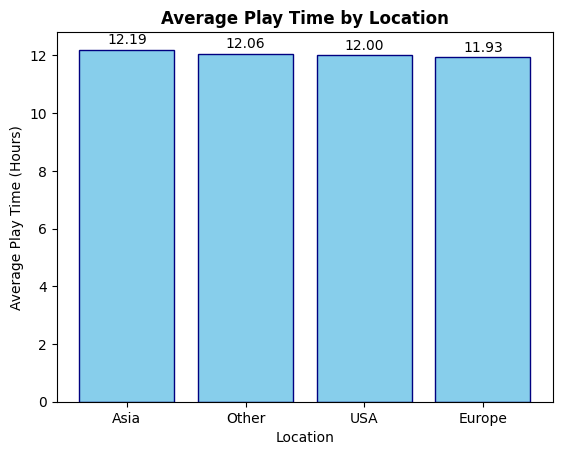

In [74]:
locations = GAMING_DATA['Location'].to_numpy()
hours = GAMING_DATA['PlayTimeHours'].to_numpy()


unique_locations = np.unique(locations)

averages = [np.mean(hours[locations == loc]) for loc in unique_locations]

sort_indices = np.argsort(averages)[::-1]
unique_locations = unique_locations[sort_indices]
averages = np.array(averages)[sort_indices]


plt.bar(unique_locations, averages, color='skyblue', edgecolor='navy')
plt.xlabel('Location')
plt.ylabel('Average Play Time (Hours)')
plt.title('Average Play Time by Location', fontweight='bold')

for i, v in enumerate(averages):
    plt.text(i, v + 0.2, f"{v:.2f}", ha='center')

plt.show()

# Does gender affect the chosen difficulty of game?

The gaming community experiences a lot of sexism (https://www.researchgate.net/publication/345054712_Sexism_in_Video_Games_and_the_Gaming_Community).
There's a general notion that women choose easier games or can't play games (that may be why they are underrepresented in eSports).
Testing difficulty by gender might prove or challenge this claim.

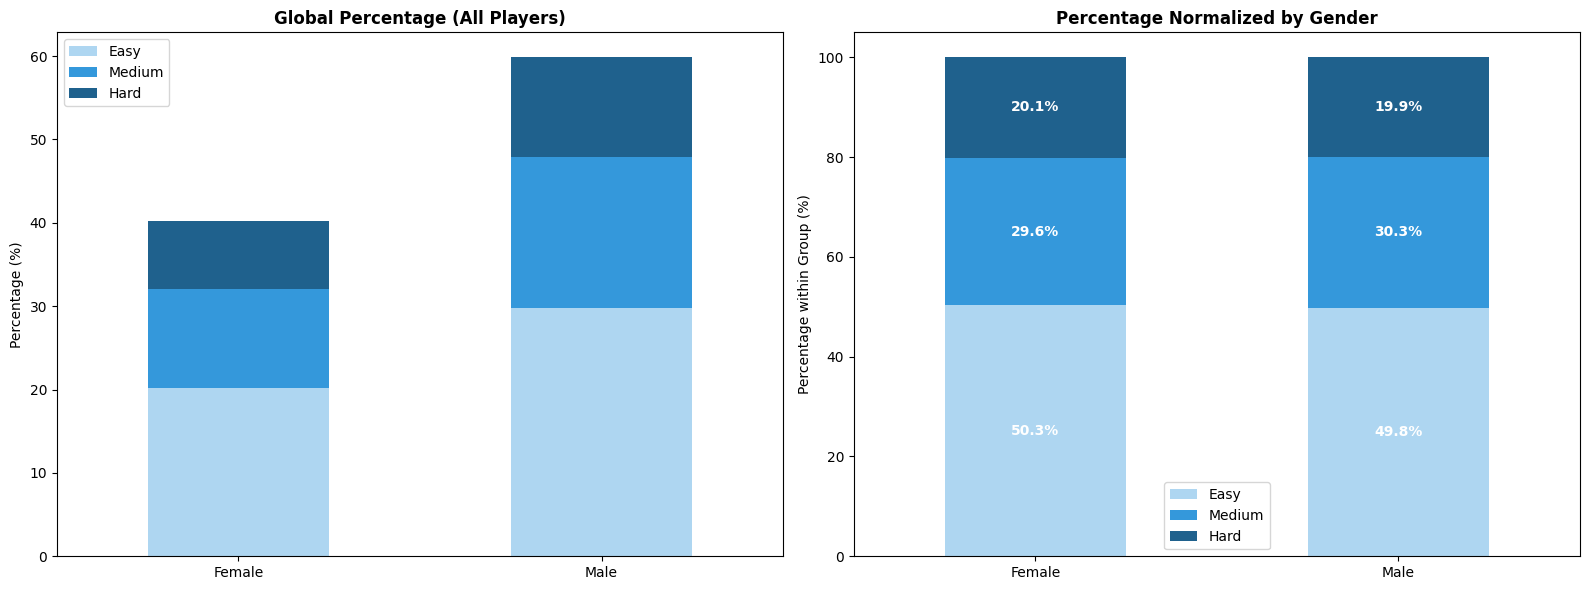

In [72]:
gender = GAMING_DATA['Gender'].to_numpy()
difficulty = GAMING_DATA['GameDifficulty'].to_numpy()

unique_genders = np.unique(gender)
unique_diffs = ['Easy', 'Medium', 'Hard']

counts = np.array([[np.sum((gender == g) & (difficulty == d)) for d in unique_diffs]for g in unique_genders])

total_pct = (counts / np.sum(counts)) * 100

within_gender_pct = (counts / counts.sum(axis=1, keepdims=True)) * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
colors = ['#aed6f1', '#3498db', '#1f618d']


pd.DataFrame(total_pct, index=unique_genders, columns=unique_diffs).plot(kind='bar', stacked=True, rot=0, ax=ax1, color=colors)
ax1.set_title('Global Percentage (All Players)', fontweight='bold')
ax1.set_ylabel('Percentage (%)')


pd.DataFrame(within_gender_pct, index=unique_genders, columns=unique_diffs).plot(kind='bar', stacked=True, rot=0, ax=ax2, color=colors)
ax2.set_title('Percentage Normalized by Gender', fontweight='bold')
ax2.set_ylabel('Percentage within Group (%)')

for c in ax2.containers:
    ax2.bar_label(c, fmt='%.1f%%', label_type='center', color='white', fontweight='bold')

plt.tight_layout()

# Do people game less when they age?

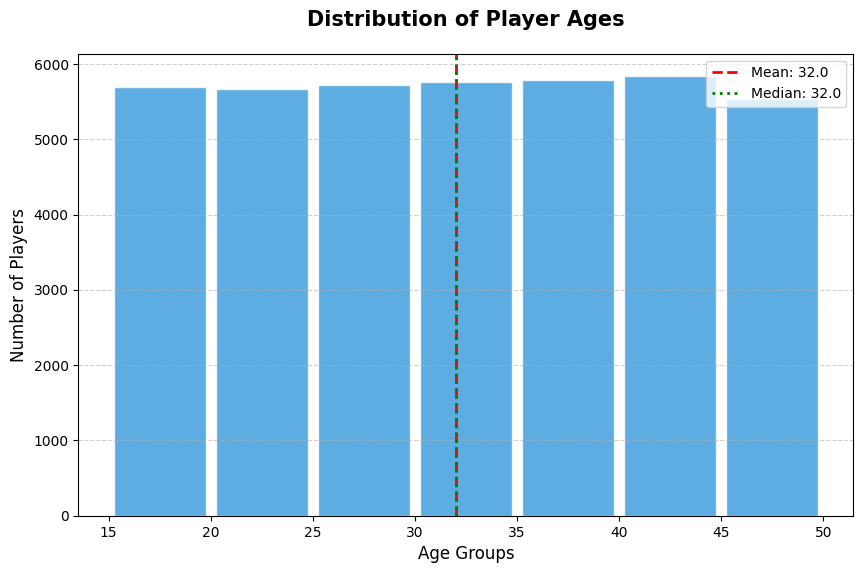

In [69]:
age = GAMING_DATA['Age'].to_numpy()
bins = [15, 20, 25, 30, 35, 40, 45, 50] 

mean_age = np.mean(age)
median_age = np.median(age)


plt.figure(figsize=(10, 6))
plt.hist(age, bins=bins, color='#3498db', edgecolor='white', alpha=0.8, rwidth=0.9)
plt.axvline(mean_age, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_age:.1f}')
plt.axvline(median_age, color='green', linestyle=':', linewidth=2, label=f'Median: {median_age:.1f}')


plt.title('Distribution of Player Ages', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Age Groups', fontsize=12)
plt.ylabel('Number of Players', fontsize=12)
plt.xticks(bins) 
plt.grid(axis='y', linestyle='--', alpha=0.6) 
plt.legend() 

# Intensity vs Purchase
Intensity score is a made-up score with the ability to express how dedicated the player are to the genre. The more time they spend on it with a higher frequency means the players are more dedicated. In-game purchase probability indicates the willingness to spend money on a game. Comparing the two allows to test whether dedication equals money spending.

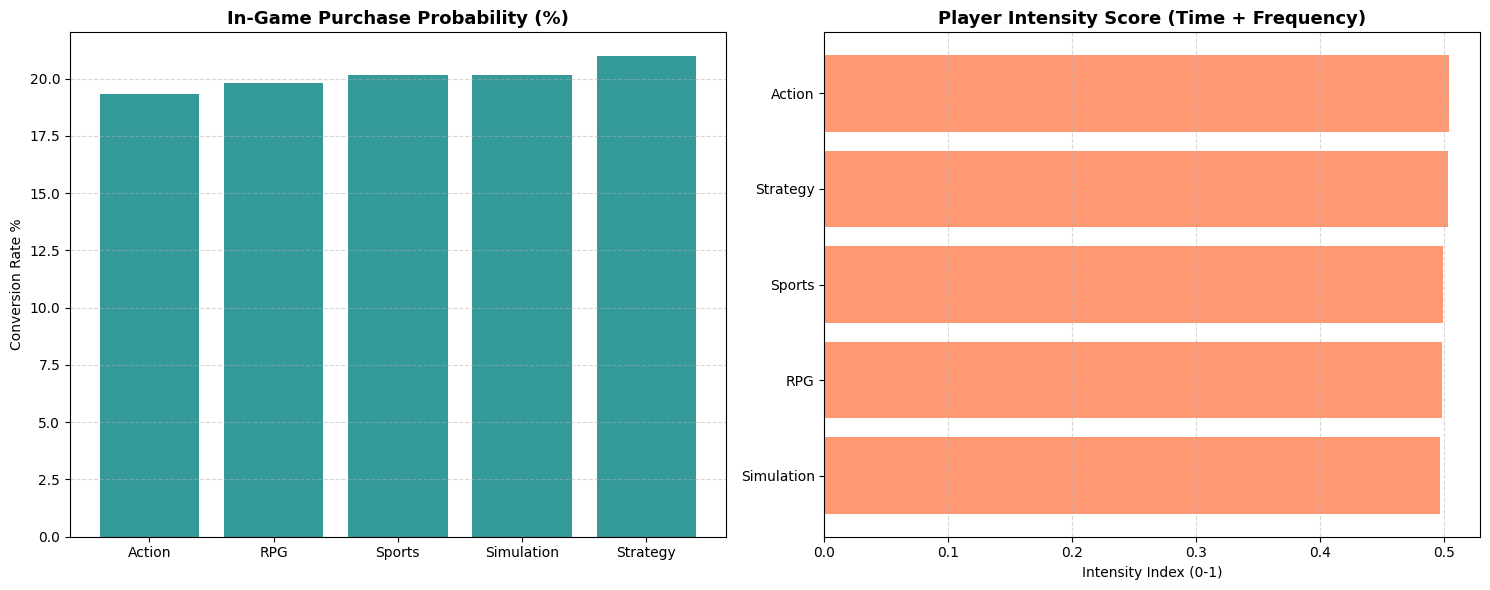

In [75]:
genre_stats = GAMING_DATA.groupby('GameGenre')['InGamePurchases'].mean().sort_values()

def scale_array(arr):
    return (arr - np.min(arr)) / (np.max(arr) - np.min(arr))

play_time_scaled = scale_array(GAMING_DATA['PlayTimeHours'].to_numpy())
sessions_scaled = scale_array(GAMING_DATA['SessionsPerWeek'].to_numpy())

GAMING_DATA['IntensityScore'] = (play_time_scaled * 0.6) + (sessions_scaled * 0.4)
intensity_by_genre = GAMING_DATA.groupby('GameGenre')['IntensityScore'].mean().sort_values()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

ax1.bar(genre_stats.index, genre_stats.values * 100, color='teal', alpha=0.8)
ax1.set_title('In-Game Purchase Probability (%)', fontsize=13, fontweight='bold')
ax1.set_ylabel('Conversion Rate %')
ax1.grid(axis='y', linestyle='--', alpha=0.5)

ax2.barh(intensity_by_genre.index, intensity_by_genre.values, color='coral', alpha=0.8)
ax2.set_title('Player Intensity Score (Time + Frequency)', fontsize=13, fontweight='bold')
ax2.set_xlabel('Intensity Index (0-1)')
ax2.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()